In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
df.info()
df.head()

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Try converting TotalCharges to numeric, and see what breaks
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# How many values failed to convert?
print(df['TotalCharges_numeric'].isna().sum())

# Look at those rows
df[df['TotalCharges_numeric'].isna()][['customerID', 'tenure', 'TotalCharges', 'Churn']]

11


,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


In [3]:
# Confirm: are all 11 blank-TotalCharges rows tenure == 0?
print(df[df['TotalCharges_numeric'].isna()]['tenure'].unique())

# Drop the temporary helper column, fix TotalCharges properly
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.drop(columns=['TotalCharges_numeric'])

# For these 11 new customers, TotalCharges should logically be 0 (no tenure = no billing yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Re-check
df.info()
print(df['TotalCharges'].isna().sum())  # should be 0 now

[0]
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Pa

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


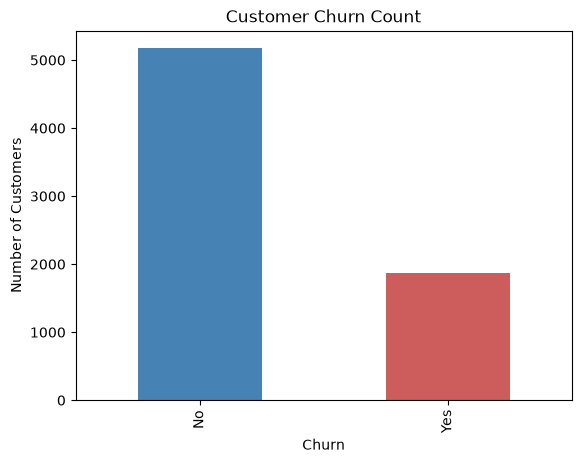

In [4]:
# Overall churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

# Quick visual
import matplotlib.pyplot as plt
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Customer Churn Count')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


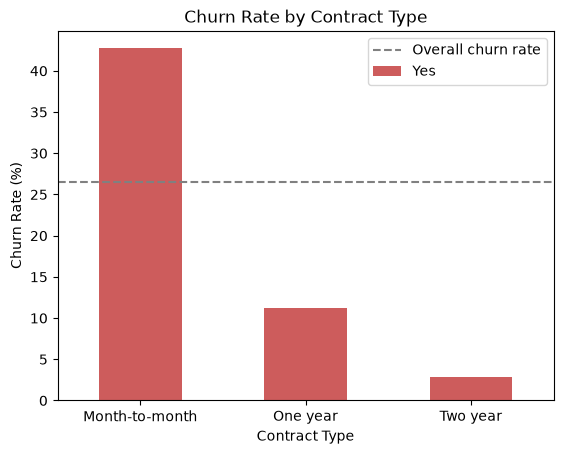

In [5]:
# Churn rate by contract type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn)

contract_churn['Yes'].plot(kind='bar', color='indianred')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.axhline(26.5, color='gray', linestyle='--', label='Overall churn rate')
plt.legend()
plt.show()

Churn                No        Yes
tenure_group                      
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


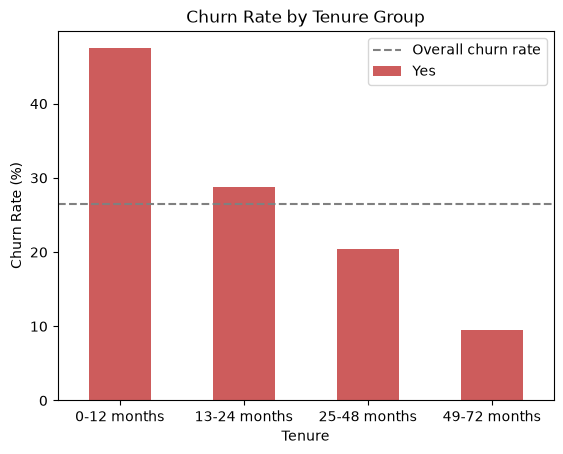

In [6]:
# Churn rate by tenure buckets
bins = [0, 12, 24, 48, 72]
labels = ['0-12 months', '13-24 months', '25-48 months', '49-72 months']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100
print(tenure_churn)

tenure_churn['Yes'].plot(kind='bar', color='indianred')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure')
plt.xticks(rotation=0)
plt.axhline(26.5, color='gray', linestyle='--', label='Overall churn rate')
plt.legend()
plt.show()

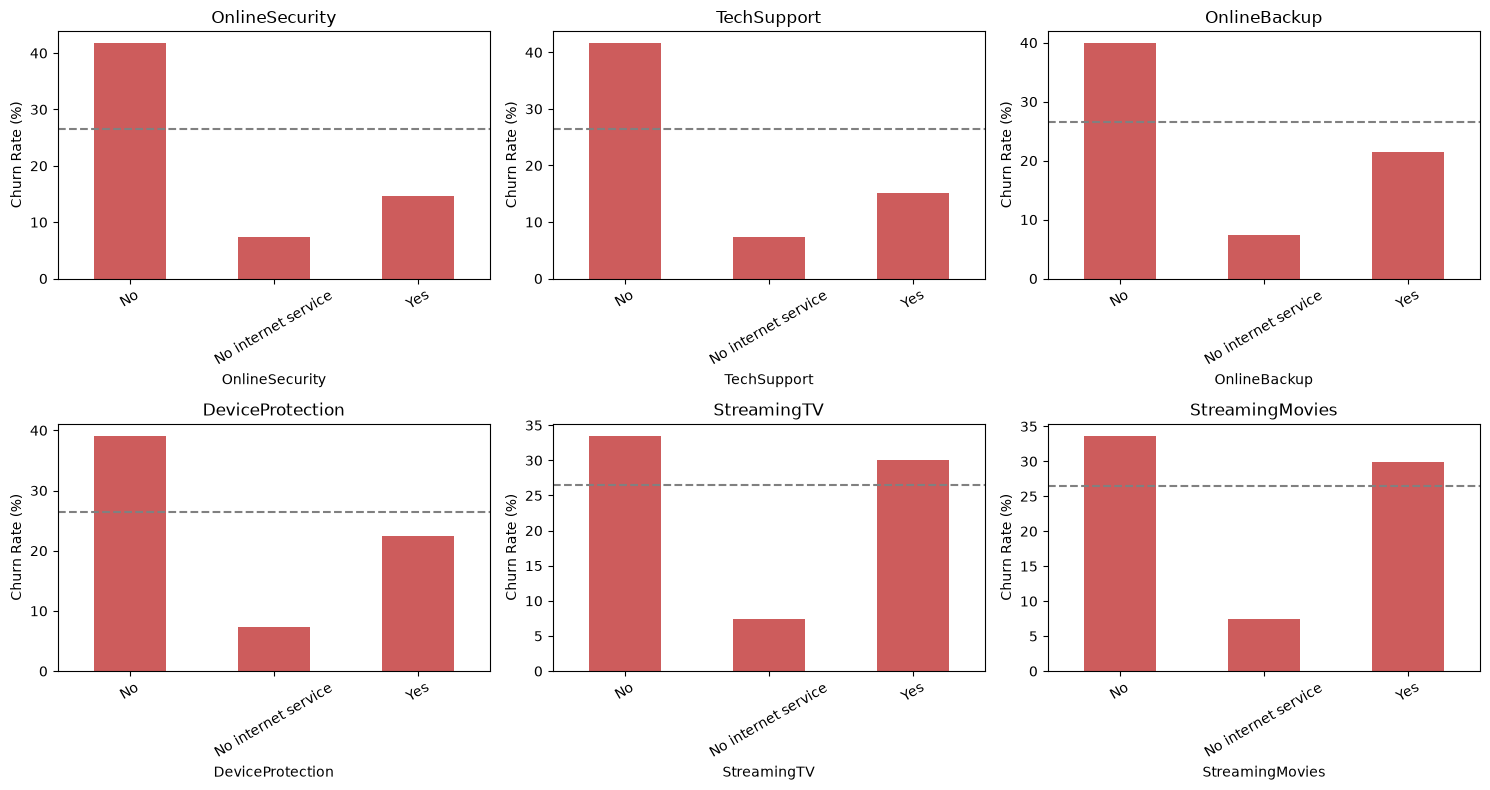

In [7]:
# Churn rate by key add-on services
services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, service in enumerate(services):
    service_churn = pd.crosstab(df[service], df['Churn'], normalize='index') * 100
    service_churn['Yes'].plot(kind='bar', ax=axes[i], color='indianred')
    axes[i].set_title(service)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].axhline(26.5, color='gray', linestyle='--')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()